<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK13_study_0529.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ch7. 5 ~ 7 (p463 ~ 487)

##7.5 DBSCAN


###DBSCAN 개요
- DBSCAN은 데이터 밀도(Density)를 기반으로 군집을 형성하는 대표적인 밀도 기반 군집화 알고리즘임.
- 원형, 고리형 등 복잡한 기하학적 형태의 데이터에서도 효과적으로 군집화를 수행할 수 있음.
- K-Means, Mean Shift, GMM이 처리하기 어려운 비정형 데이터 분포에도 우수한 성능을 보임.
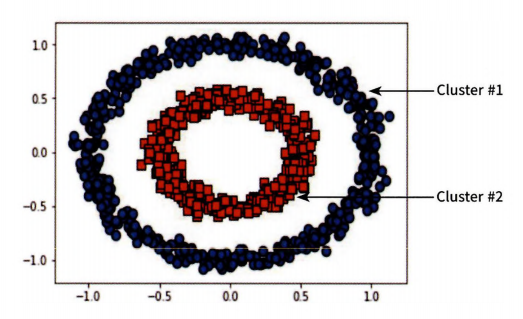

####주요 파라미터
- 주변 영역(epsilon)
  - 개별 데이터를 중심으로 입실론 반경을 가지는 원형의 영역
- 최소 데이터 개수(min points)
  - 개별 데이터의 입실론 주변 영역에 포함되는 타 데이터의 개수

####데이터 포인트
- 입실론 주변 영역 내에 포함되는 최소 데이터 개수를 충족시키는가 아닌가에 따라 정의
- 핵심 포인트(Core Point)
  - 주변 영역 내에 최소 데이터 개수 이상의 타 데이터를 가지고 있을 경우
- 이웃 포인트(Neighbor Point)
  - 주변 영역 내에 위치한 타 데이터
- 경계 포인트(Border Point)
  - 주변 영역 내에 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않지만
  - 핵심 포인트를 이웃 포인트로 가지고 있는 데이터
- 잡음 포인트(Noise Point)
  - 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않음.
  - 핵심 포인트도 이웃 포인트로 가지고 있지 않는 데이터

### DBSCAN 군집화 핵심 요약

DBSCAN은 **밀도(density)** 를 기준으로 군집을 만드는 알고리즘입니다. 예시에서는:

* 반경(**eps**) 내에 최소 **6개 데이터(자기 자신 포함)** 가 있어야 핵심 포인트가 됨

#### 1. 핵심 포인트(Core Point)

* 반경 내 데이터 수가 최소 개수 이상인 점
* 예:

  * **P1**: 반경 내 7개 데이터 → 핵심 포인트
  * **P2**: 반경 내 6개 데이터 → 핵심 포인트

#### 2. 군집 형성 방식

* 핵심 포인트끼리 직접 연결될 수 있으면 같은 군집으로 묶음
* 예:

  * P1과 P2가 모두 핵심 포인트이며 서로 이웃 → 연결 가능
* 이런 연결을 계속 확장하면서 군집을 생성

#### 3. 경계 포인트(Border Point)

* 스스로는 핵심 포인트가 될 만큼 이웃이 많지 않음
* 하지만 이웃 중에 핵심 포인트가 존재함
* 예:

  * **P3**는 이웃이 P2, P4뿐이라 핵심 포인트는 아님
  * 하지만 핵심 포인트인 P2와 연결되어 있어 경계 포인트가 됨
* 군집의 가장자리를 형성

#### 4. 잡음 포인트(Noise Point)

* 최소 데이터 수를 만족하지 못하고
* 주변에 핵심 포인트도 없는 점
* 예:

  * **P5**
* 어떤 군집에도 속하지 않음

---

### DBSCAN의 핵심 아이디어

1. **핵심 포인트(Core Point)** 를 찾는다.
2. 서로 연결 가능한 핵심 포인트들을 묶어 군집을 만든다.
3. 핵심 포인트 주변의 **경계 포인트(Border Point)** 를 군집에 포함시킨다.
4. 어느 군집에도 속하지 않는 점은 **잡음 포인트(Noise Point)** 로 처리한다.

---

### Scikit-learn DBSCAN 주요 파라미터

* **eps**

  * 이웃을 판단하는 반경(입실론)
  * 값이 클수록 더 많은 점이 이웃으로 포함됨

* **min_samples**

  * 핵심 포인트가 되기 위해 eps 반경 내에 필요한 최소 데이터 수
  * 자기 자신도 포함
  * 값이 클수록 핵심 포인트가 되기 어려움

**한 줄 정리:**
DBSCAN은 "주변에 충분히 많은 데이터가 모여 있는 점(핵심 포인트)"들을 연결하여 군집을 만들고, 가장자리 점은 경계 포인트로 포함하며, 고립된 점은 잡음으로 처리하는 밀도 기반 군집화 알고리즘이다.
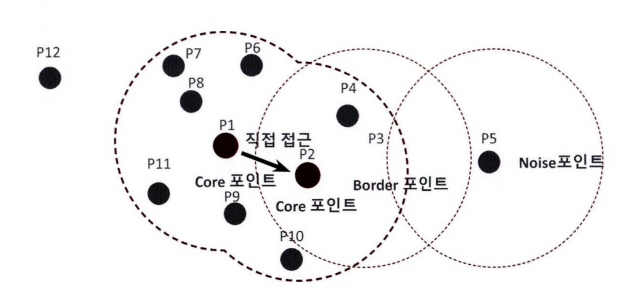

###DBSCAN 적용하기 - 붓꽃 데이터 세트

In [9]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the iris dataset
iris = load_iris()

# Create a DataFrame for iris data
irisDF = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [10]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=8, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64


- DBSCAN에서 군집 레이블 -1은 노이즈(이상치) 군집을 의미함.
- 붓꽃 데이터는 DBSCAN에 의해 0과 1의 두 개 군집으로 자동 분류됨.
- DBSCAN은 군집 수를 미리 지정하지 않으며, 이 경우 3개보다 2개 군집이 더 효율적인 군집화 결과를 보임.

In [14]:
import numpy as np
from matplotlib import pyplot as plt

def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
    if dataframe is None:
        print("Error: DataFrame is required.")
        return

    unique_labels = np.unique(dataframe[label_name])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name] == label]
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                    marker=markers[label % len(markers)])

    if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
        # Assuming cluster_result has a .cluster_centers_ attribute
        center_x_y = cluster_result.cluster_centers_[label]
        plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
                    marker=markers[label % len(markers)])
        plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
                    marker='$%d$' % label)

    plt.show()

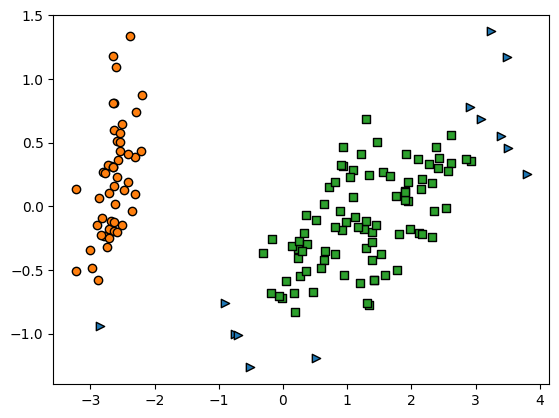

In [15]:
from sklearn.decomposition import PCA
# 2차원으로 시각화하기 위해 PCA n_components=2로 피처 데이터 세트 변환
pca = PCA(n_components=2, random_state=0)
pca_transformed = pca.fit_transform(iris.data)
# visualize_cluster_plot() 함수는 ftr1, ftr2 칼럼을 좌표에 표현하므로 PCA 변환값을 해당 칼럼으로 생성
irisDF['ftr1'] = pca_transformed[:,0]
irisDF['ftr2'] = pca_transformed[:,1]

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

- ★로 표시된 값은 모두 노이즈(이상치) 이며, PCA로 2차원 시각화를 하면 쉽게 확인할 수 있음.
- DBSCAN은 군집 개수를 강제로 지정하기보다 eps와 min_samples를 조정해 최적의 군집을 찾는 것이 중요함.
- 일반적으로 eps가 커지면 노이즈는 감소하고, min_samples가 커지면 노이즈는 증가함.

target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64


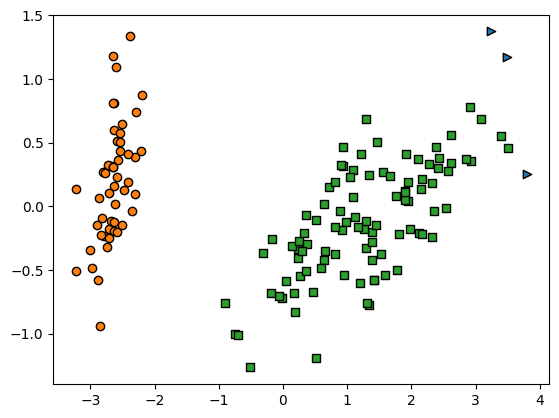

In [16]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=8, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

- eps를 증가시키자 노이즈 군집(-1)에 속한 데이터가 3개만 남음.
- 반경이 넓어지면서 기존에 노이즈였던 일부 데이터가 Cluster 1에 포함됨.

target  dbscan_cluster
0        0                48
        -1                 2
1        1                44
        -1                 6
2        1                36
        -1                14
Name: count, dtype: int64


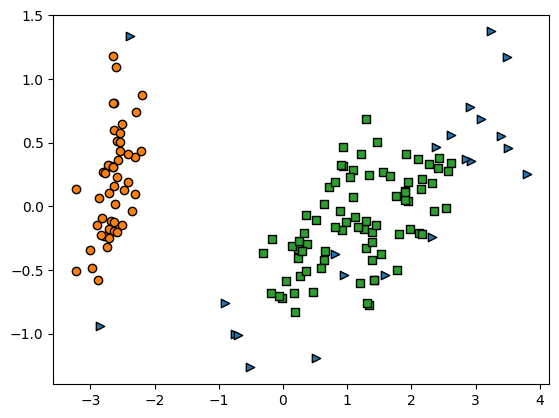

In [17]:
# eps는 0.6으로 유지한 채 min_samples를 16으로 증가시켜 결과 변화 확인하기
dbscan = DBSCAN(eps=0.6, min_samples=16, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

- 노이즈가 기존보다 많이 증가함.

###DBSCAN 적용하기 - make_circles() 데이터 세트
- 복잡한 기하학적 구조를 가진 데이터에서 DBSCAN과 다른 군집화 알고리즘을 비교함.
- 이를 위해 make_circles() 함수로 내부 원과 외부 원 형태의 2차원 데이터 세트를 생성함.
- noise는 노이즈 비율을, factor는 내부 원과 외부 원의 크기 비율을 조정하는 파라미터임.

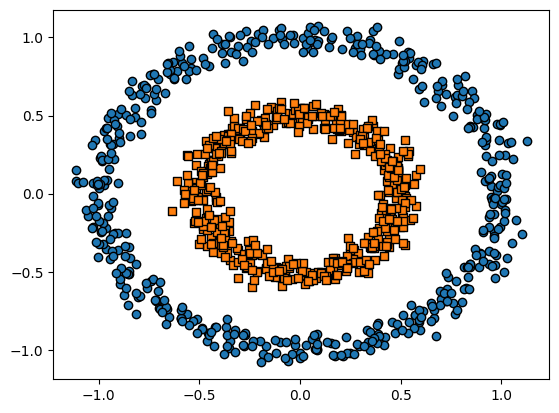

In [18]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, shuffle=True, noise=0.05, random_state=0, factor=0.5)
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

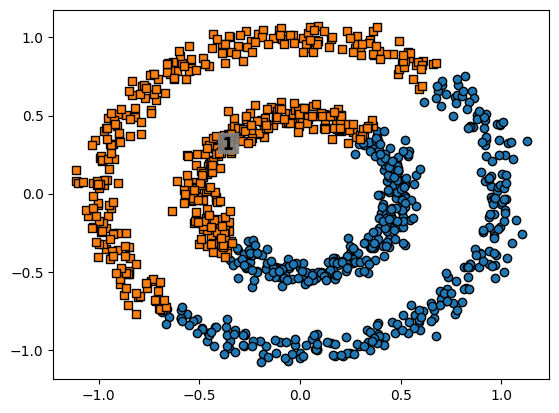

In [19]:
# KMeans로 make_circles() 데이터 세트를 군집화 수행.
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels = kmeans.fit_predict(X)
clusterDF['kmeans_cluster'] = kmeans_labels

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_cluster', iscenter=True)

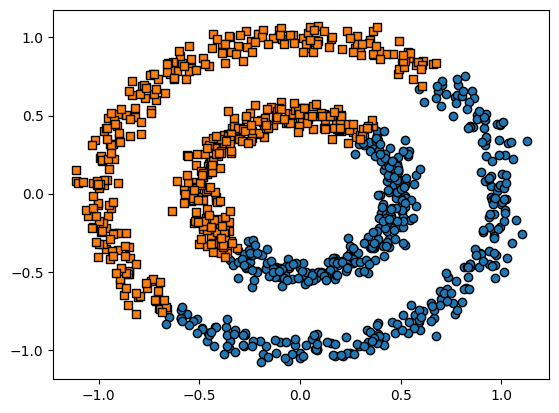

In [20]:
# GMM으로 make_circles() 데이터 세트를 군집화 수행.
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=0)
gmm_label = gmm.fit(X).predict(X)
clusterDF['gmm_cluster'] = gmm_label

visualize_cluster_plot(gmm, clusterDF, 'gmm_cluster', iscenter=False)

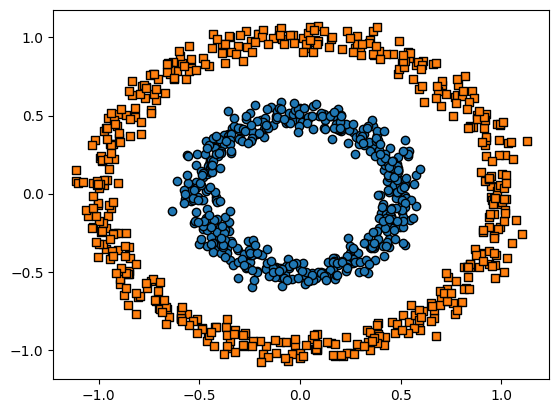

In [21]:
# DBSCAN으로 make_circles() 데이터 세트 군집화 수행.
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=10, metric='euclidean')
dbscan_labels = dbscan.fit_predict(X)
clusterDF['dbscan_cluster'] = dbscan_labels
visualize_cluster_plot(dbscan, clusterDF, 'dbscan_cluster', iscenter=False)

##7.6 군집화 실습 - 고객 세그먼테이션

###고객 세그먼테이션의 정의와 기법
- 다양한 기준으로 고객을 분류하는 기법
- 기준
  - 개인의 신상 데이터
  - 어떤 상품을 얼마나 많은 비용을 써서 얼마나 자주 사용하는가
  - 얼마나 많은 매출을 발생하느냐
- 목표: 타겟 마케팅
  - 고객을 여러 특성에 맞게 세분화해서 그 유형에 따라 맞춤형 마케팅이나 서비스를 제공하는 것
  - 고객의 상품 구매 이력이 중요

####RFM 기법
- Recency(R): 가장 최근 상품 구입 일에서 오늘까지의 기간
- Frequency(F): 상품 구매 횟수
- Monetary value(M): 총 구매 금액


###데이터 세트 로딩과 데이터 클렌

In [22]:
import pandas as pd
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

retail_df = pd.read_excel(io='Online Retail.xlsx')
retail_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [23]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


- 전체 데이터는 541,909건이지만 **CustomerID 결측치가 약 13만 5천 건으로 매우 많아 데이터 정제가 필요함**.
- 고객 세분화를 위해 **CustomerID가 없는 데이터는 제거하고**, `Quantity ≤ 0` 또는 `UnitPrice ≤ 0`인 오류·반품 데이터도 삭제함.
- 이후 **`Quantity > 0`, `UnitPrice > 0`, `CustomerID`가 Not Null인 데이터만 필터링하여 분석에 사용함**.



In [24]:
retail_df = retail_df[retail_df['Quantity'] > 0]
retail_df = retail_df[retail_df['UnitPrice'] > 0]
retail_df = retail_df[retail_df['CustomerID'].notnull()]
print(retail_df.shape)
retail_df.isnull().sum()

(397884, 8)


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [25]:
retail_df['Country'].value_counts()[:5]

,count
Country,
United Kingdom,354321
Germany,9040
France,8341
EIRE,7236
Spain,2484


In [26]:
retail_df = retail_df[retail_df['Country']=='United Kingdom']
print(retail_df.shape)

(354321, 8)


###RFM 기반 데이터 가공

In [27]:
retail_df['sale_amount'] = retail_df['Quantity'] * retail_df['UnitPrice']
retail_df['CustomerID'] = retail_df['CustomerID'].astype(int)

In [37]:
print(retail_df['CustomerID'].value_counts().head(5))
print(retail_df.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False).iloc[:5])

CustomerID
17841    7847
14096    5111
12748    4595
14606    2700
15311    2379
Name: count, dtype: int64
CustomerID
18102    259657.30
17450    194550.79
16446    168472.50
17511     91062.38
16029     81024.84
Name: sale_amount, dtype: float64


In [38]:
retail_df.groupby(['InvoiceNo', 'StockCode'])['InvoiceNo'].count().mean()

np.float64(1.028702077315023)

- RFM 고객 세분화는 **고객별 최근 구매일(Recency), 구매 빈도(Frequency), 구매 금액(Monetary)** 을 기준으로 수행함.
- 이를 위해 주문 단위 데이터를 **CustomerID 기준으로 `groupby()`** 하여 고객 단위 데이터로 변환하고, `agg()`를 사용해 여러 집계 연산을 동시에 적용함.
- Frequency는 주문 건수(`InvoiceNo` count), Monetary는 총 구매금액(`sale_amount` sum), Recency는 가장 최근 주문일(`InvoiceDate` max)을 구한 뒤 추가 가공함.


In [39]:
# DataFrame의 groupby()의 multiple 연산을 위해 agg() 이용
# Recency는 InvoiceDate 칼럼의 max()에서 데이터 가공
# Frequency는 InvoiceNo 칼럼의 count(), Monetary value는 sale_amount 칼럼의 sum()
aggregations = {
    'InvoiceDate': 'max',
    'InvoiceNo': 'count',
    'sale_amount': 'sum'
}
cust_df = retail_df.groupby('CustomerID').agg(aggregations)
# groupby된 결과 칼럼 값을 Recency, Frequency, Monetary로 변경
cust_df = cust_df.rename(columns = {'InvoiceDate': 'Recency',
                                    'InvoiceNo': 'Frequency',
                                    'sale_amount': 'Monetary'
}
)
cust_df = cust_df.reset_index()
cust_df.head(3)

,CustomerID,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12747,2011-12-07 14:34:00,103,4196.01
2,12748,2011-12-09 12:20:00,4595,33719.73


- Recency는 고객의 **최근 주문일 자체가 아니라 마지막 구매 후 경과한 일수**를 의미함.
- 데이터의 마지막 날짜가 2011-12-09이므로 기준일을 **2011-12-10**으로 설정하여 계산함.
- 기준일에서 고객별 최근 주문일을 뺀 후 **일(day) 단위 값만 추출해 Recency를 생성함**.


In [40]:
import datetime as dt

cust_df['Recency'] = dt.datetime(2011, 12, 10) - cust_df['Recency']
cust_df['Recency'] = cust_df['Recency'].apply(lambda x: x.days+1)
print('cust_df 로우와 칼럼 수는 ', cust_df.shape)
cust_df.head(3)

cust_df 로우와 칼럼 수는  (3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,3,103,4196.01
2,12748,1,4595,33719.73


###RFM 기반 고객 세그멘테이션
- 온라인 판매 데이터는 **대량 구매 고객 때문에 주문 횟수(Frequency)와 주문 금액(Monetary)의 분포가 심하게 왜곡되어 있음**.
- 이러한 왜곡된 분포에서는 군집화 결과가 일부 큰 고객에게 치우쳐 **특정 군집에 데이터가 집중되는 문제가 발생함**.
- 따라서 군집화 전에 `Recency`, `Frequency`, `Monetary`의 히스토그램을 확인하여 데이터 분포를 분석함.


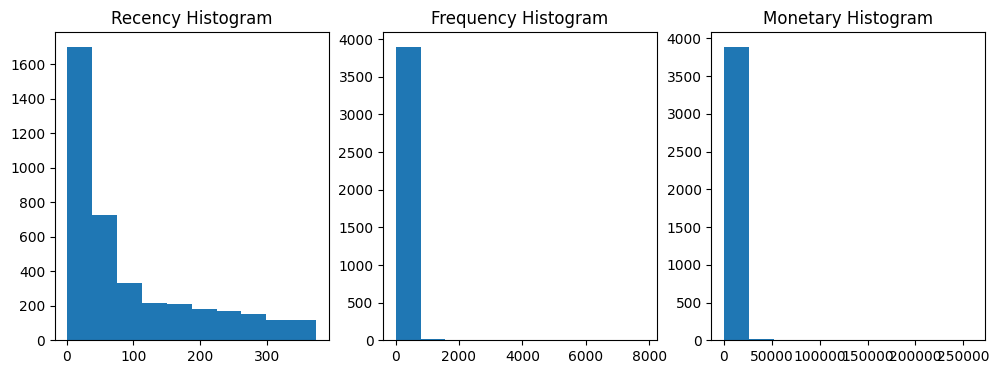

In [41]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
ax1.set_title('Recency Histogram')
ax1.hist(cust_df['Recency'])

ax2.set_title('Frequency Histogram')
ax2.hist(cust_df['Frequency'])

ax3.set_title('Monetary Histogram')
ax3.hist(cust_df['Monetary'])
plt.show()

In [42]:
cust_df[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,92.742092,90.388010,1864.385601
std,99.533485,217.808385,7482.817477
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,300.280000
50%,51.000000,41.000000,652.280000
75%,143.000000,99.250000,1576.585000
max,374.000000,7847.000000,259657.300000


- Recency, Frequency, Monetary 모두 **최댓값이 매우 크고 평균이 왜곡되어 있어 데이터 분포의 치우침이 심함**.
- 특히 Frequency와 Monetary는 일부 대규모 고객의 영향으로 평균이 크게 높아져 이상치의 영향을 많이 받음.
- 이러한 데이터에 K-평균을 적용하면 군집 구분이 잘되지 않으므로, 먼저 **StandardScaler로 표준화한 후 군집화를 수행함**.


In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

X_features = cust_df[['Recency', 'Frequency', 'Monetary']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label'] = labels

print('실루엣 스코어는: {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

실루엣 스코어는: 0.576


- 군집 수를 3개로 설정했을 때 **평균 실루엣 스코어는 0.576로 양호한 수준을 보임**.
- 하지만 평균값만으로는 군집 품질을 정확히 판단할 수 없으므로 **각 군집의 개별 실루엣 계수와 데이터 분포를 함께 확인해야 함**.
- 이를 위해 군집 수를 2~5개로 변경하면서 실루엣 계수와 군집 구성을 시각화하여 비교 분석함.


In [44]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA

def visualize_silhouette(cluster_lists, X_features):
    # Visualize Silhouette for each cluster_lists
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)

    for ind, n_cluster in enumerate(cluster_lists):
        kmeans = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(X_features)

        silhouette_avg = silhouette_score(X_features, cluster_labels)
        sample_silhouette_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : ' + str(n_cluster) + '\n' \
                           'Silhouette Score :' + str(round(silhouette_avg, 3)))
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        for i in range(n_cluster):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, \
                                   facecolor=color, edgecolor=color, alpha=0.7)

            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=silhouette_avg, color="red", linestyle="--")

    plt.tight_layout()
    plt.show()


def visualize_kmeans_plot_multi(cluster_lists, X_features, iscenter=False):
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)

    pca = PCA(n_components=2, random_state=0)
    pca_transformed = pca.fit_transform(X_features)

    dataframe = pd.DataFrame(data=pca_transformed, columns=['ftr1', 'ftr2'])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for ind, n_cluster in enumerate(cluster_lists):
        kmeans = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(X_features)
        dataframe['cluster'] = cluster_labels

        unique_labels = np.unique(dataframe['cluster'])

        for label in unique_labels:
            label_cluster = dataframe[dataframe['cluster'] == label]
            axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                             marker=markers[label % len(markers)])

        if iscenter and hasattr(kmeans, 'cluster_centers_'):
            center_x_y = pca.transform(kmeans.cluster_centers_)
            for label, center in enumerate(center_x_y):
                axs[ind].scatter(x=center[0], y=center[1], s=200, color='gray', alpha=0.9,
                                 marker=markers[label % len(markers)])
                axs[ind].scatter(x=center[0], y=center[1], s=70, color='k', edgecolor='k',
                                 marker='$%d$' % label)

        axs[ind].set_title('Number of Cluster : ' + str(n_cluster))
        axs[ind].set_xlabel('ftr1')
        axs[ind].set_ylabel('ftr2')

    plt.tight_layout()
    plt.show()

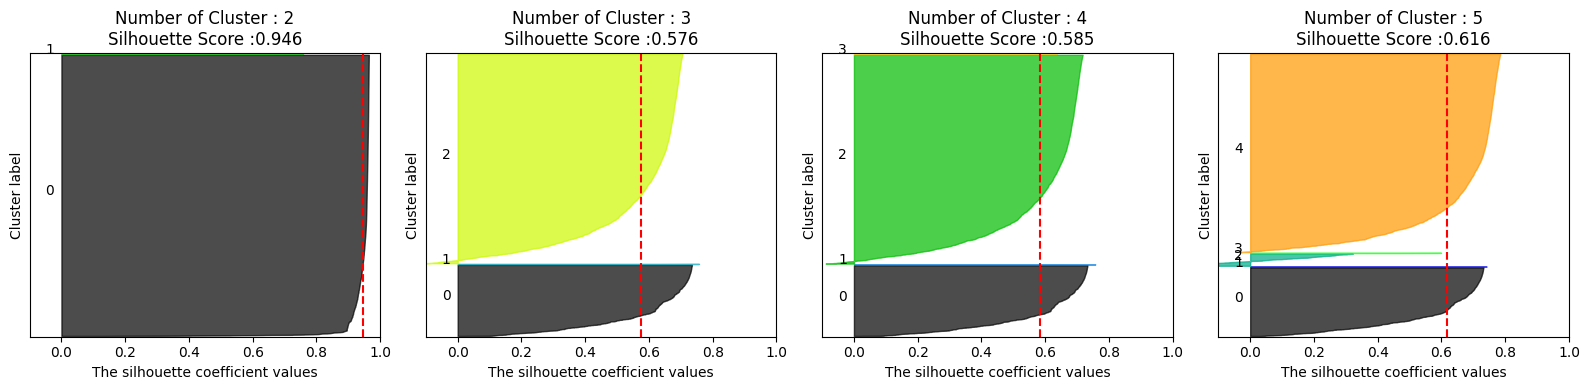

/tmp/ipykernel_546/589009334.py:70: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
/tmp/ipykernel_546/589009334.py:70: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',


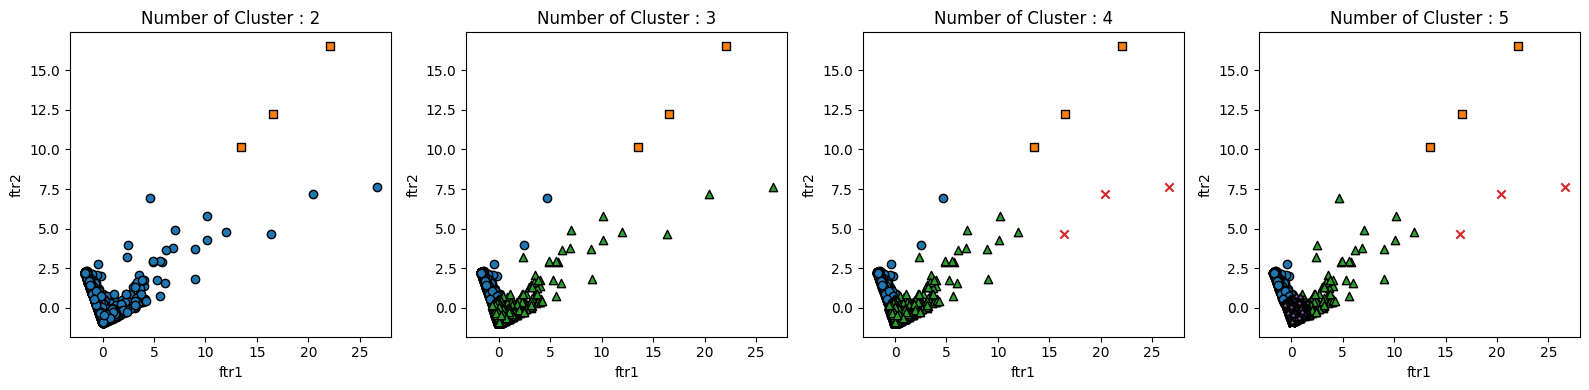

In [45]:
visualize_silhouette([2,3,4,5], X_features_scaled)
visualize_kmeans_plot_multi([2,3,4,5], X_features_scaled)

- 군집 수를 늘려도 품질이 좋아지지 않고, **일부 대량 구매 고객만 별도 군집으로 계속 분리되는 현상**이 발생함.
- 이는 데이터 분포가 심하게 왜곡되어 있어 K-평균이 **의미 있는 새로운 군집보다 이상치성 고객을 중심으로 군집을 생성하기 때문임**.
- 따라서 왜곡을 줄이기 위해 **로그(Log) 변환을 적용한 후 K-평균 군집화를 수행하여 결과를 개선함**.


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Recency, Frequency, Monetary 칼럼에 np.log1p()로 Log Transformation
cust_df['Recency_log'] = np.log1p(cust_df['Recency'])
cust_df['Frequency_log'] = np.log1p(cust_df['Frequency'])
cust_df['Monetary_log'] = np.log1p(cust_df['Monetary'])

# Log Transformation 데이터에 StandardScaler 적용
X_features = cust_df[['Recency_log', 'Frequency_log', 'Monetary_log']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label'] = labels

print('실루엣 스코어는: {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

실루엣 스코어는: 0.303


- 로그 변환 후에는 **실루엣 스코어가 다소 낮아졌지만**, 군집들이 이전보다 더 균형 있고 고르게 형성됨.
- 군집화에서는 실루엣 스코어의 절대값보다 **각 군집이 얼마나 균일하고 의미 있게 분리되는지가 더 중요함**.
- 따라서 왜곡이 큰 데이터는 **로그 변환으로 분포를 완화한 후 군집화를 수행하는 것이 더 나은 결과를 제공함**.


- K-평균은 거리 기반으로 군집 중심을 이동시키며 단순하고 직관적이지만 복잡한 구조나 군집 수 결정에 한계가 있음.
- 평균 이동과 GMM은 각각 밀도 기반 접근과 확률적 정규분포 가정을 통해 더 유연하게 군집을 형성하지만 계산 비용이 크거나 시간이 오래 걸리는 단점이 있음.
- DBSCAN은 밀도 기반으로 핵심·경계·노이즈 포인트를 구분해 군집을 만들며 구조가 복잡한 데이터에도 잘 적용되는 직관적인 알고리즘임.
